/tmp/ipython-input-3065055681.py:16: FutureWarning: YF.download() has changed argument auto_adjust default to True
  stock_data = yf.download(ticker, start=start_date, end=end_date)
[*********************100%***********************]  1 of 1 completed


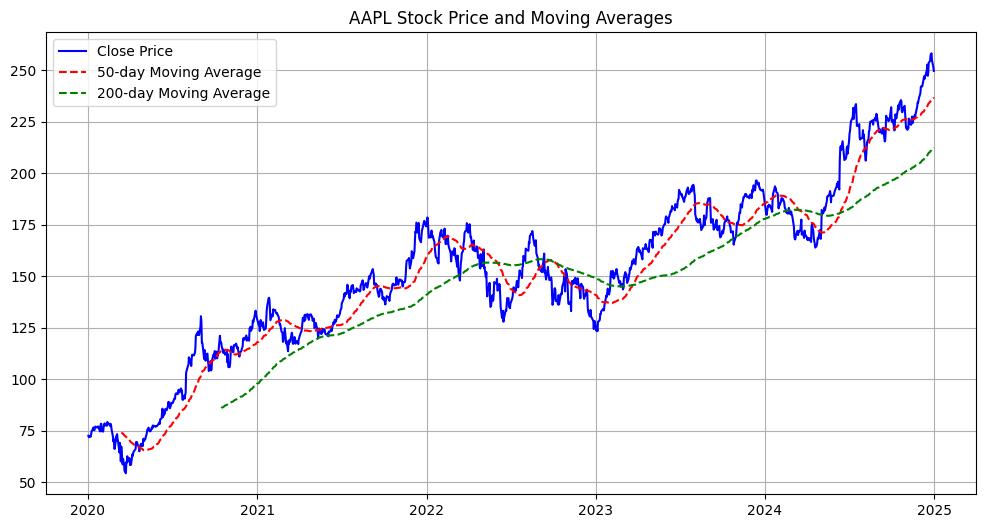

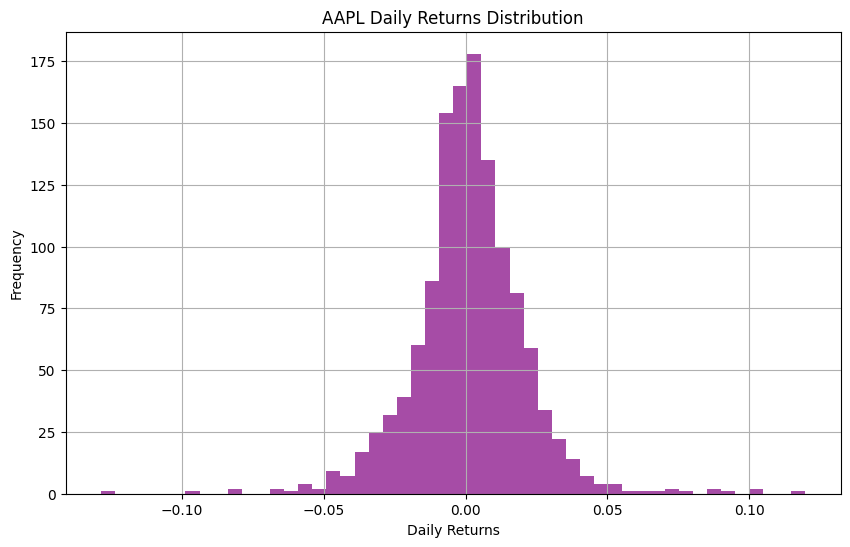

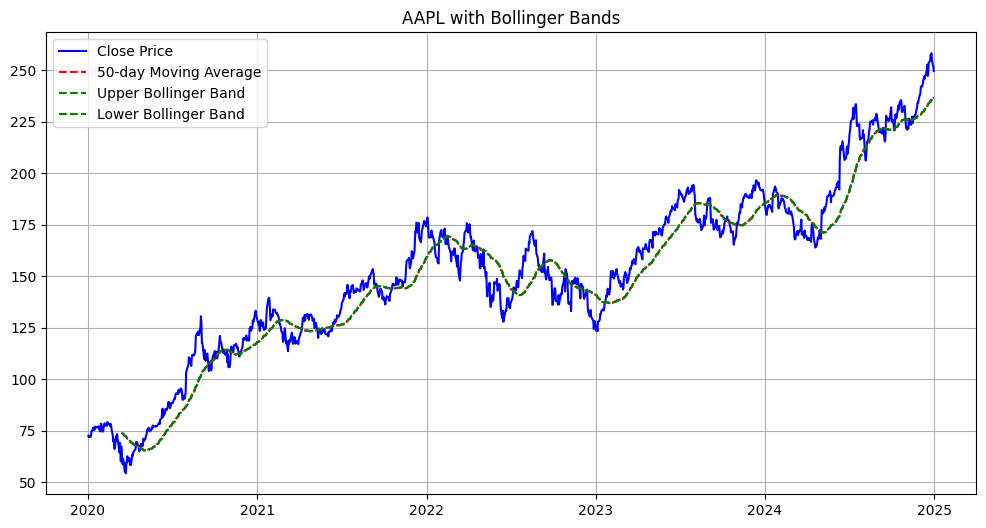

In [1]:
# Install required libraries
!pip install yfinance pandas matplotlib numpy

# Import libraries
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Step 1: Download stock data
ticker = 'AAPL'  # You can change this to any stock ticker
start_date = '2020-01-01'
end_date = '2025-01-01'

# Fetch data from Yahoo Finance
stock_data = yf.download(ticker, start=start_date, end=end_date)

# Display the first few rows of the stock data
stock_data.head()

# Step 2: Calculate Moving Averages
stock_data['50_MA'] = stock_data['Close'].rolling(window=50).mean()  # 50-day Moving Average
stock_data['200_MA'] = stock_data['Close'].rolling(window=200).mean()  # 200-day Moving Average

# Step 3: Calculate Returns
stock_data['Daily_Return'] = stock_data['Close'].pct_change()  # Daily returns

# Step 4: Calculate Volatility (Standard deviation of returns)
stock_data['Volatility'] = stock_data['Daily_Return'].rolling(window=50).std()

# Step 5: Visualization - Plot the stock data
plt.figure(figsize=(12, 6))

# Plot Close Price and Moving Averages
plt.plot(stock_data['Close'], label='Close Price', color='blue')
plt.plot(stock_data['50_MA'], label='50-day Moving Average', color='red', linestyle='--')
plt.plot(stock_data['200_MA'], label='200-day Moving Average', color='green', linestyle='--')
plt.title(f'{ticker} Stock Price and Moving Averages')
plt.legend(loc='best')
plt.grid(True)
plt.show()

# Step 6: Distribution of Daily Returns
plt.figure(figsize=(10, 6))
plt.hist(stock_data['Daily_Return'].dropna(), bins=50, color='purple', alpha=0.7)
plt.title(f'{ticker} Daily Returns Distribution')
plt.xlabel('Daily Returns')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

# Step 7: Calculate and Plot the Bollinger Bands
stock_data['Upper_Band'] = stock_data['50_MA'] + 2 * stock_data['Volatility']
stock_data['Lower_Band'] = stock_data['50_MA'] - 2 * stock_data['Volatility']

plt.figure(figsize=(12, 6))
plt.plot(stock_data['Close'], label='Close Price', color='blue')
plt.plot(stock_data['50_MA'], label='50-day Moving Average', color='red', linestyle='--')
plt.plot(stock_data['Upper_Band'], label='Upper Bollinger Band', color='green', linestyle='--')
plt.plot(stock_data['Lower_Band'], label='Lower Bollinger Band', color='green', linestyle='--')
plt.title(f'{ticker} with Bollinger Bands')
plt.legend(loc='best')
plt.grid(True)
plt.show()


This code downloads historical stock data for Apple (AAPL) from Yahoo Finance, calculates key indicators like 50-day and 200-day moving averages, daily returns, and volatility, and visualizes trends using line charts. It also analyzes the stock’s behavior with a histogram of daily returns and Bollinger Bands, highlighting periods when the stock may be overbought or oversold. Overall, it transforms raw price data into actionable insights about trends, risk, and market behavior.

In [2]:
def compute_rsi(data, window=14):
    delta = data['Close'].diff()
    gain = (delta.where(delta > 0, 0)).rolling(window=window).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=window).mean()
    rs = gain / loss
    rsi = 100 - (100 / (1 + rs))
    return rsi

stock_data['RSI'] = compute_rsi(stock_data)


This introduces the Relative Strength Index (RSI), a key indicator of a stock’s momentum. RSI measures the speed and magnitude of recent price changes to show whether the stock is overbought (likely to drop) or oversold (likely to rise). The function calculates daily gains and losses, averages them over a 14-day window, computes the relative strength, and converts it to a 0–100 scale. By adding the RSI to stock_data, we now have a momentum “compass” that helps highlight turning points in Apple’s stock story.

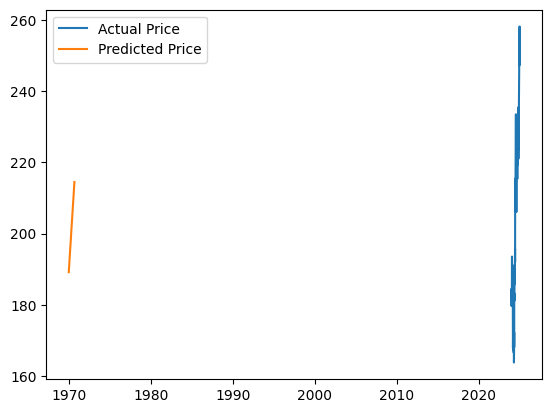

In [3]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

# Prepare the data
stock_data['Date'] = stock_data.index
stock_data['Date'] = stock_data['Date'].map(pd.Timestamp.toordinal)  # Convert dates to ordinal values for regression

X = stock_data[['Date']]
y = stock_data['Close']

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

# Linear regression model
model = LinearRegression()
model.fit(X_train, y_train)

# Prediction
predictions = model.predict(X_test)
plt.plot(y_test, label='Actual Price')
plt.plot(predictions, label='Predicted Price')
plt.legend()
plt.show()


This piece of code tries to predict Apple’s stock closing price using a simple linear regression. It first converts the dates into numerical values (ordinal format) because regression models work with numbers, not dates. Then it splits the data into training and testing sets (80% for training, 20% for testing) without shuffling, to preserve the chronological order of stock prices. The LinearRegression model is trained on the training set to learn the trend over time, and finally, it predicts closing prices for the test set. The results are visualized with a plot comparing the actual prices versus the predicted prices, showing how well (or poorly) the model captures the trend.

I attempted to make a linear regression model here but the graph that was output was rather lackluster.  The preducted price was in the 1970s and very off from the actual price in the 2020s

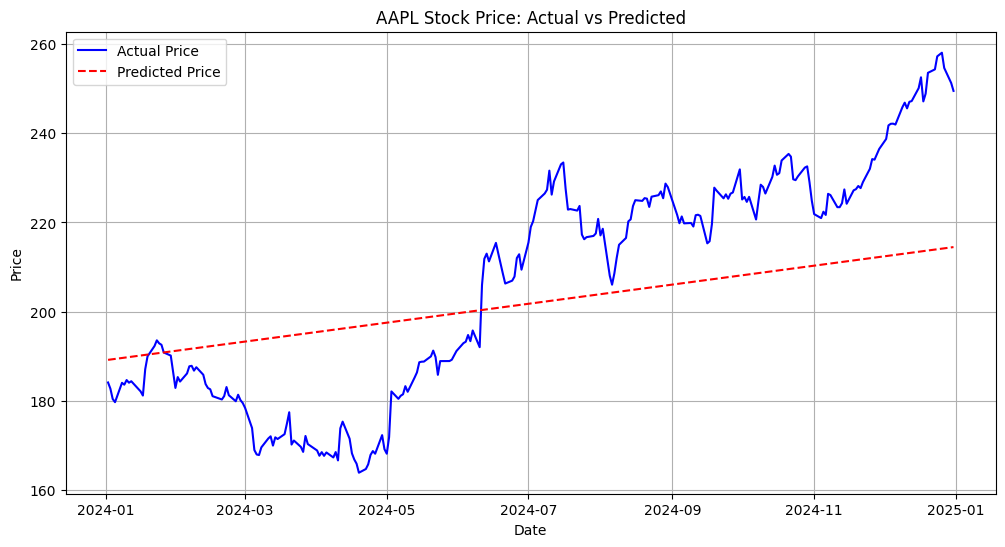

In [4]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import pandas as pd

# Prepare the data: convert dates to ordinal for regression input
stock_data['Date_ordinal'] = stock_data.index.map(pd.Timestamp.toordinal)

X = stock_data[['Date_ordinal']]
y = stock_data['Close']

# Split the data into train and test sets without shuffling (time series!)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

# Create and fit the linear regression model
model = LinearRegression()
model.fit(X_train, y_train)

# Predict closing prices on test set
y_pred = model.predict(X_test)

# Plot actual and predicted prices using the original datetime index for the test set
plt.figure(figsize=(12, 6))
plt.plot(y_test.index, y_test, label='Actual Price', color='blue')
plt.plot(y_test.index, y_pred, label='Predicted Price', color='red', linestyle='--')
plt.xlabel('Date')
plt.ylabel('Price')
plt.title(f'{ticker} Stock Price: Actual vs Predicted')
plt.legend()
plt.grid(True)
plt.show()


This snippet uses linear regression to model Apple’s stock price over time. First, it converts the date index into ordinal numbers so the regression model can work with time as a numeric variable. Then it splits the data into training and testing sets without shuffling, preserving the chronological order—a crucial step for time-series data. The model is trained on the training set, and predictions are made for the test set. Finally, it visualizes actual vs. predicted stock prices using the original datetime index, giving a clear picture of how well the model captures trends over the selected period.  y plotting against the original datetime index instead of ordinal numbers, the predicted prices now align correctly on the timeline, fixing the earlier issue where predictions appeared decades in the past.

I mapped the datetime index to ordinal numbers only for training the model.  When plotting, I used the original datetime index (y_test.index) to correctly align the time axis.  Now the predicted prices are displayed on the same timeline as the actual prices.

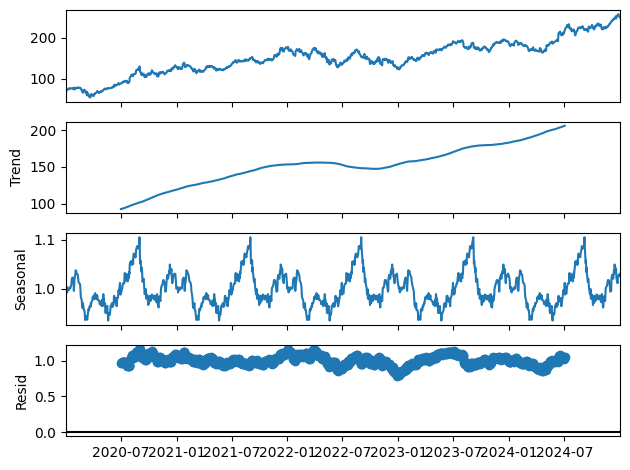

In [5]:
from statsmodels.tsa.seasonal import seasonal_decompose

decomposition = seasonal_decompose(stock_data['Close'], model='multiplicative', period=252)  # Assuming daily data
decomposition.plot()
plt.show()


This code performs a seasonal decomposition on Apple’s closing stock prices, breaking the time series into its underlying components. It separates the data into a trend, showing the long-term direction of the stock; a seasonal component, capturing recurring patterns or cycles such as yearly effects; and a residual component, which represents random fluctuations not explained by trend or seasonality. By assuming a period of 252 trading days, the decomposition is able to highlight annual patterns in the stock data. Finally, the results are plotted, providing a clear visual understanding of how much of the stock’s movement is driven by trend, cyclical behavior, or random volatility.

In [6]:
risk_free_rate = 0.02  # Example risk-free rate (e.g., from government bonds)
mean_return = stock_data['Daily_Return'].mean()
std_dev = stock_data['Daily_Return'].std()

sharpe_ratio = (mean_return - risk_free_rate) / std_dev
print(f'Sharpe Ratio: {sharpe_ratio}')


Sharpe Ratio: -0.942984854149166


This snippet calculates the Sharpe Ratio, a key measure of risk-adjusted return for Apple’s stock. It first defines a risk-free rate (such as the return from government bonds) and computes the stock’s average daily return and daily return volatility (standard deviation). The Sharpe Ratio is then calculated by subtracting the risk-free rate from the stock’s mean return and dividing by the volatility, giving a single number that reflects how much return the stock generates for each unit of risk taken. A higher Sharpe Ratio indicates that the stock offers better returns relative to the risk, helping investors compare performance across different assets.

In [7]:
stock_data[['Close', '50_MA', '200_MA']].corr()


,Price,Close,50_MA,200_MA
,Ticker,AAPL,,
Price,Ticker,,,
Close,AAPL,1.000000,0.967825,0.872756
50_MA,,0.967825,1.000000,0.924578
200_MA,,0.872756,0.924578,1.000000


/tmp/ipython-input-2979223894.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  stock_data['Signal'][stock_data['50_MA'] > stock_data['200_MA']] = 1
/tmp/ipython-input-2979223894.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  stock_data['Signal'][stock_data['50_MA'] > stock_data['200_MA']] = 1
/tmp/ipython-input-2979223894.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  stock_data['Signal'][stock_data['50_MA'] < stock_data['

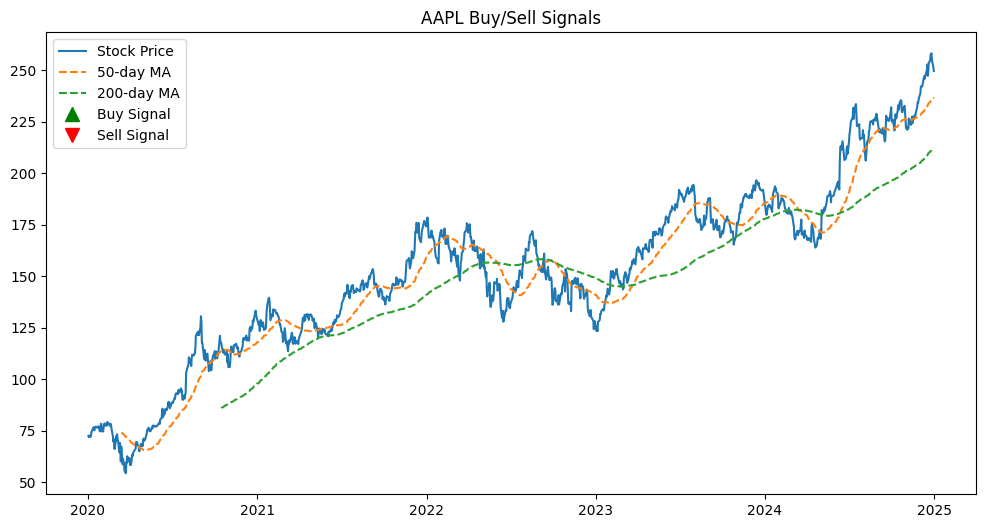

In [8]:
# Create signals
stock_data['Signal'] = 0
stock_data['Signal'][stock_data['50_MA'] > stock_data['200_MA']] = 1
stock_data['Signal'][stock_data['50_MA'] < stock_data['200_MA']] = -1

# Plot Buy/Sell signals
plt.figure(figsize=(12, 6))
plt.plot(stock_data['Close'], label='Stock Price')
plt.plot(stock_data['50_MA'], label='50-day MA', linestyle='--')
plt.plot(stock_data['200_MA'], label='200-day MA', linestyle='--')
plt.plot(stock_data[stock_data['Signal'] == 1].index,
         stock_data['50_MA'][stock_data['Signal'] == 1], 'g^', markersize=10, label='Buy Signal')
plt.plot(stock_data[stock_data['Signal'] == -1].index,
         stock_data['50_MA'][stock_data['Signal'] == -1], 'rv', markersize=10, label='Sell Signal')
plt.title(f'{ticker} Buy/Sell Signals')
plt.legend(loc='best')
plt.show()


This code generates trading signals based on the classic moving average crossover strategy. It creates a signal column in the stock data, assigning a value of 1 (buy) when the 50-day moving average crosses above the 200-day moving average, and -1 (sell) when the 50-day moving average crosses below the 200-day moving average. These signals are then plotted alongside the stock price and both moving averages, with green triangles indicating buy points and red inverted triangles indicating sell points, providing a visual guide for potential entry and exit opportunities based on trend-following strategies.

In [9]:
stock = yf.Ticker(ticker)
financials = stock.financials
print(financials)


                                                      2024-09-30  \
Tax Effect Of Unusual Items                         0.000000e+00   
Tax Rate For Calcs                                  2.410000e-01   
Normalized EBITDA                                   1.346610e+11   
Net Income From Continuing Operation Net Minori...  9.373600e+10   
Reconciled Depreciation                             1.144500e+10   
Reconciled Cost Of Revenue                          2.103520e+11   
EBITDA                                              1.346610e+11   
EBIT                                                1.232160e+11   
Net Interest Income                                          NaN   
Interest Expense                                             NaN   
Interest Income                                              NaN   
Normalized Income                                   9.373600e+10   
Net Income From Continuing And Discontinued Ope...  9.373600e+10   
Total Expenses                                  

This code fetches financial statements for the selected stock using the yfinance library. By creating a Ticker object for Apple and accessing its financials attribute, it retrieves key financial data such as income statements, revenues, expenses, and net income. Printing this information provides a quick overview of the company’s financial health, which can complement technical analysis by adding a fundamental perspective on the stock’s performance.

In [10]:
max_drawdown = (stock_data['Close'] / stock_data['Close'].cummax() - 1).min()
summary_stats = {
    "Mean Return": mean_return,
    "Volatility": std_dev,
    "Sharpe Ratio": sharpe_ratio,
    "Max Drawdown": max_drawdown
}
print(summary_stats)


{'Mean Return': np.float64(0.001182110661692909), 'Volatility': 0.01995566445792605, 'Sharpe Ratio': np.float64(-0.942984854149166), 'Max Drawdown': Ticker
AAPL   -0.314273
dtype: float64}


This is a final key summary of the statistics of the stock.  From maximum drawdown, a measurement of the largest peak-to-trough decline in the stock's price, it creates a dictionary containing the mean daily return, volatility, share ratio, and max drawdown.  This provides a quick overview of the stock’s average performance, risk, and potential losses, giving a clear snapshot of its historical behavior.

In this project, I performed a comprehensive analysis of Apple’s stock (AAPL) from 2020 to 2025, combining technical and fundamental approaches. The project explores historical price trends with moving averages, Bollinger Bands, and buy/sell signals, evaluates momentum using RSI, and examines long-term patterns through linear regression and seasonal decomposition. Risk and performance were assessed using daily returns, volatility, Sharpe ratio, and maximum drawdown, while key financial statements provided a fundamental perspective on the company’s health. Cumulative returns and visualizations highlight how $1 invested would have grown over time, offering both practical insights and actionable observations. Overall, this analysis demonstrates the integration of multiple tools and techniques to understand stock behavior, identify trends, and evaluate risk.